#### E-Commerce Customer Segmentation/clustering System

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
data = pd.read_csv("D:\Courses\AI-ML PRIME\AIML - Projects\Minor-Projects\SmartCard Clustering System\smartcart_customers.csv")

data.head()
data.shape

(2240, 22)

In [7]:
data.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

## Data Preprocessing

### 1. Handling Missing Values

In [12]:
data["Income"] = data["Income"].fillna(data["Income"].median())

In [13]:
data.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

## Feature Engineering

In [14]:
data.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response'],
      dtype='object')

In [ ]:
# Adding he new feature ---> Age
max_year = data["Year_Birth"].max()

data["Age"] = max_year - data["Year_Birth"]


1893

In [21]:
data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,88,88,3,8,10,4,7,0,1,69
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,1,6,2,1,1,2,5,0,0,72
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,21,42,1,8,2,10,4,0,0,61
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,3,5,2,2,0,4,6,0,0,42
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,27,15,5,5,3,6,5,0,0,45


In [26]:
data["Dt_Customer"] = pd.to_datetime(data["Dt_Customer"], dayfirst=True)

reference_date = data["Dt_Customer"].max()

data["Customer_Tenure_Days"]= (reference_date - data["Dt_Customer"]).dt.days

In [27]:
data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,88,3,8,10,4,7,0,1,69,663
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,6,2,1,1,2,5,0,0,72,113
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,42,1,8,2,10,4,0,0,61,312
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,5,2,2,0,4,6,0,0,42,139
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,15,5,5,3,6,5,0,0,45,161


In [30]:
# Adding 2 More new features----> Totoal purchases and total children

data["Total_spending"] = data["MntWines"] + data["MntFruits"] + data["MntMeatProducts"] + data["MntFishProducts"] + data["MntSweetProducts"] + data["MntGoldProds"]

data["Total_Children"] = data["Kidhome"] + data["Teenhome"]


In [31]:
data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_spending,Total_Children
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,8,10,4,7,0,1,69,663,1617,0
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,1,1,2,5,0,0,72,113,27,2
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,8,2,10,4,0,0,61,312,776,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,2,0,4,6,0,0,42,139,53,1
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,3,6,5,0,0,45,161,422,1


In [33]:
## Education  ---- > Graduate, Undergraduate, Postgraduate

data["Education"].value_counts()

data["Education"] =data["Education"].replace({
    "Basic" :"Undergraduate",
    "2n Cycle" : "Undergraduate",
    "Master" : "Postgraduate",
    "PhD" : "Postgraduate"
})

In [34]:
data["Education"].value_counts()

Education
Graduation       1127
Postgraduate      856
Undergraduate     257
Name: count, dtype: int64

In [35]:
### Martial Status

data["Marital_Status"].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [36]:
## Lets create new feature Living_with

data["Living_with"] = data["Marital_Status"].replace({
    "Married" : "Partner",
    "Together" : "Partner",
    "Divorced" : "Alone",
    "Widow" : "Alone",
    "Single" : "Alone",
    "Absurd" : "Alone",
    "YOLO" : "Alone"
})

data["Living_with"].value_counts()

Living_with
Partner    1444
Alone       796
Name: count, dtype: int64

### Dropping Columns

In [38]:
columns = ["ID", "Year_Birth", "Marital_Status", "Dt_Customer","Kidhome","Teenhome"]
spending_cols = ["MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds"]

cols_to_drop = columns + spending_cols

data_cleaned = data.drop(columns=cols_to_drop)

In [39]:
data_cleaned.shape

(2240, 15)

## Handling Outliers

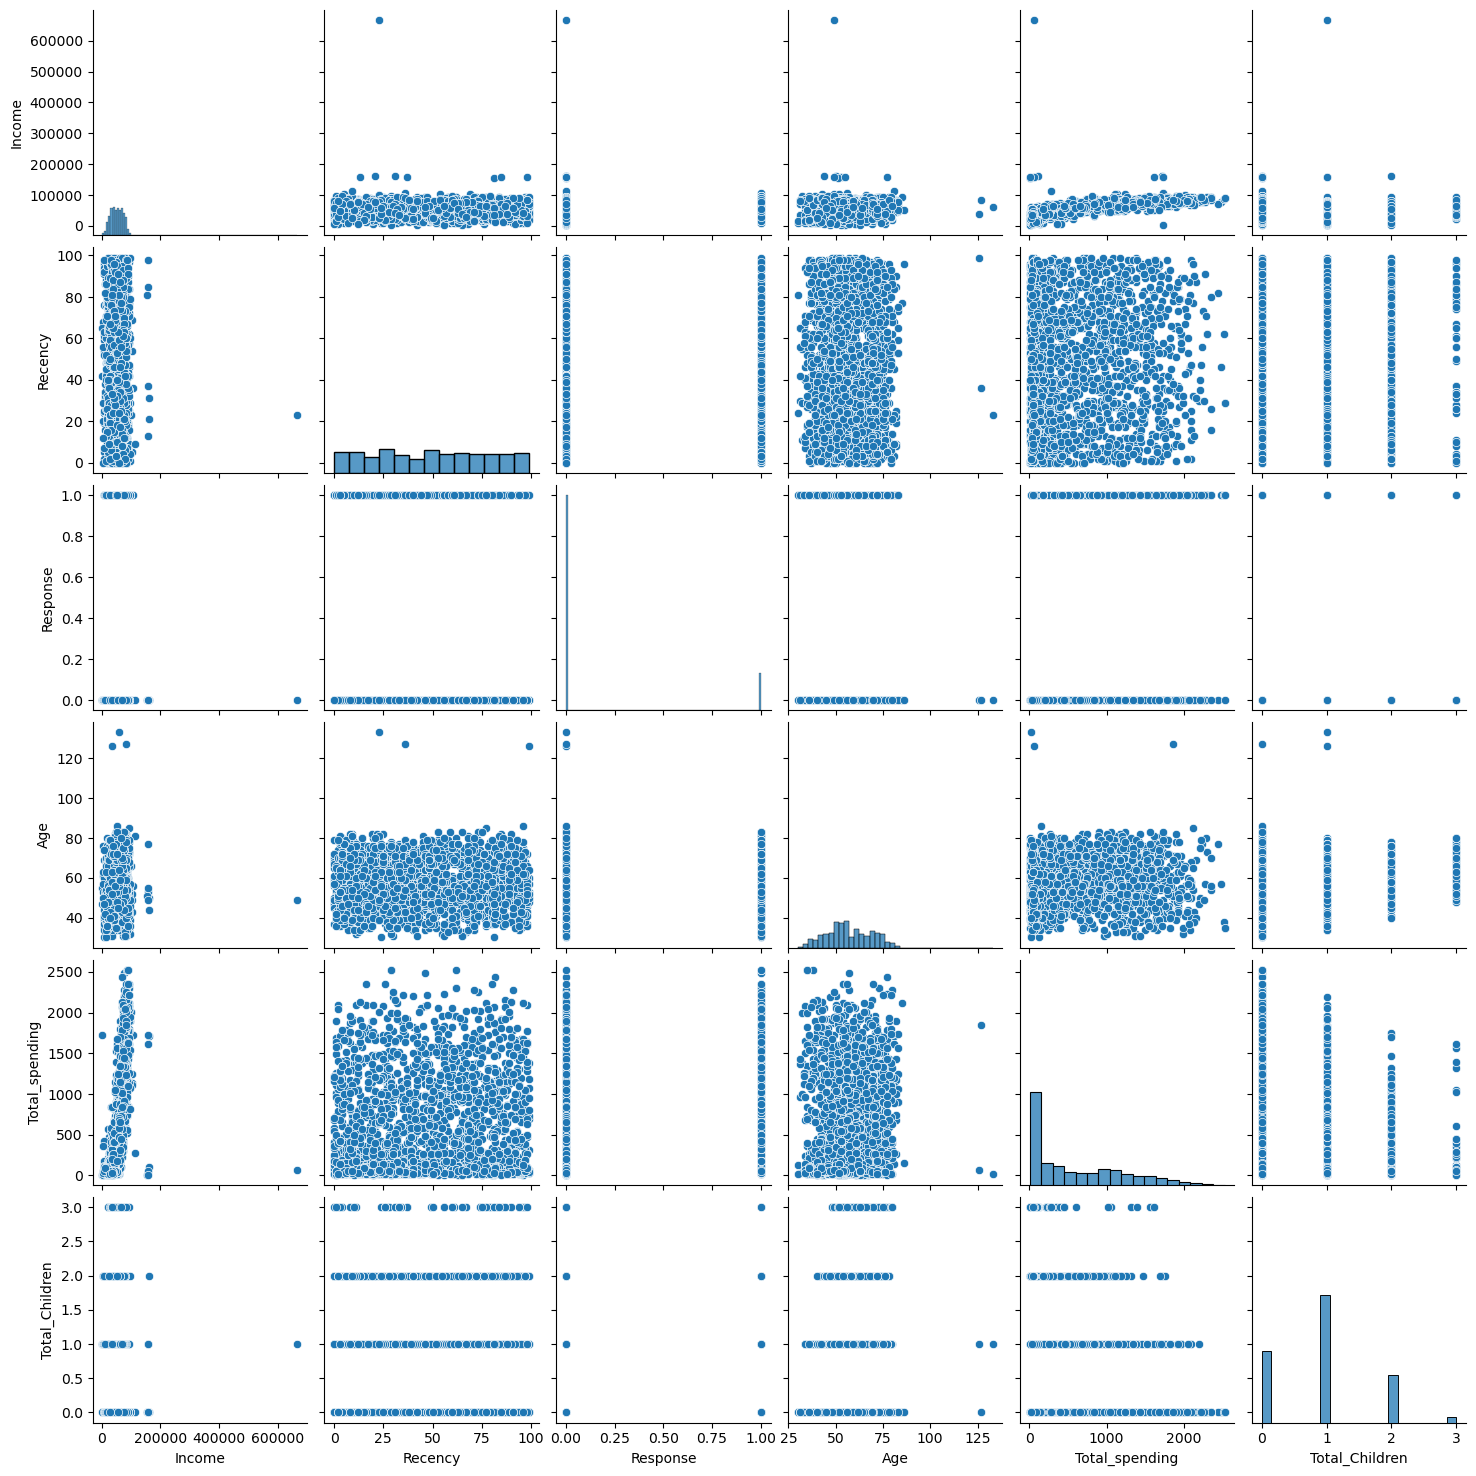

In [41]:
cols = ["Income", "Recency", "Response","Age","Total_spending","Total_Children"]

# Relative plots of some features --- pair plots to look for outliers
sns.pairplot(data_cleaned[cols])

In [42]:
# 3 Removed outliers from the dataset

print("data size with outliers: ", len(data_cleaned))

data_cleaned = data_cleaned[data_cleaned["Age"] < 90]
data_cleaned = data_cleaned[data_cleaned["Income"] < 600_000]

print("data size without outliers: ", len(data_cleaned))



data size with outliers:  2240
data size without outliers:  2236
